# Model Project: A Consumer with Two Nests

Problems 1 to 3: the model, solving it numerically, and relative prices

The model is a nested CES consumer who buys three goods: food, bus and train. Bus and train sit together in a travel nest. The model itself (utility, shares, quantities) lives in consumer.py. Here I import it and do the analysis with figures and text.

Everything is run for two calibrations that only differ in how easily bus and train can replace each other: complements (sigma_B = 0.40) and substitutes (sigma_B = 3.00).

## Setup

In [38]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3d projection)

from consumer import ConsumerClass

# plotting defaults, matching the course style
plt.rcParams.update({'axes.grid':True,'grid.color':'black',
                     'grid.alpha':0.25,'grid.linestyle':'-','font.size':12})
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The two calibrations only differ in sigma_B. I build the second model with par={'sigma_B':3.0}, so no code gets duplicated.

In [39]:
model_c = ConsumerClass()                      # complements, sigma_B = 0.40 (baseline)
model_s = ConsumerClass(par={'sigma_B':3.0})   # substitutes, sigma_B = 3.00

models = {'complements':model_c, 'substitutes':model_s}

for name,m in models.items():
    print(f'--- {name} ---'); print(m); print()

--- complements ---
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

--- substitutes ---
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000



## 1. The model

The consumer buys three goods x1, x2, x3 >= 0 at prices p1, p2, p3 > 0 with income I > 0. Good 1 is food, goods 2 and 3 are bus and train, which sit in a travel nest.

Utility is built in two steps, one per nest. First bus and train are combined into a travel composite,
$$x_B = \left(\beta x_2^{\rho_B} + (1-\beta)x_3^{\rho_B}\right)^{1/\rho_B},$$
and then food and travel are combined into utility,
$$u(x_1,x_2,x_3) = \left(\alpha x_1^{\rho_A} + (1-\alpha)x_B^{\rho_A}\right)^{1/\rho_A},$$
with $\rho = 1-\tfrac{1}{\sigma}$. That is what utility() does: two calls to ces(), one per nest.

sigma_B is the important part here:

sigma_B < 1 (complements): bus and train go together. The consumer wants both and cannot just drop one of them.

sigma_B > 1 (substitutes): bus and train can replace each other, so the consumer mostly buys the cheaper one.

### 1.1 The problem in nested budget shares

Instead of choosing three quantities with a budget constraint, I choose two nested budget shares: s1 in [0,1] (share of income on food) and w in [0,1] (share of the travel budget on bus). The three budget shares then follow as
$$s_1,\qquad s_2=(1-s_1)w,\qquad s_3=(1-s_1)(1-w),$$
and the quantities are $x_j=s_jI/p_j$.

Why that trick is smart. Whatever (s1,w) I pick in the unit square, the three shares sum to 1, so the budget constraint holds automatically. It cannot be broken. So the constraint set is exactly the box [0,1] x [0,1], and that is what L-BFGS-B takes as bounds. No penalties, no constraint handling. It is the same idea as section 6.4 in the optimization lecture.

In [40]:
# demonstrate the (s1,w) -> shares -> quantities mapping at an arbitrary point
s1_demo, w_demo = 0.5, 0.4
for name,m in models.items():
    s1,s2,s3 = m.shares(s1_demo,w_demo)
    x1,x2,x3 = m.quantities(s1_demo,w_demo)
    u = m.value_of_choice(s1_demo,w_demo)
    print(f'{name}: (s1,s2,s3)=({s1:.3f},{s2:.3f},{s3:.3f}), sum={s1+s2+s3:.3f}, '
          f'(x1,x2,x3)=({x1:.3f},{x2:.3f},{x3:.3f}), u={u:.4f}')

complements: (s1,s2,s3)=(0.500,0.200,0.300), sum=1.000, (x1,x2,x3)=(5.000,2.000,2.000), u=3.3784
substitutes: (s1,s2,s3)=(0.500,0.200,0.300), sum=1.000, (x1,x2,x3)=(5.000,2.000,2.000), u=3.3784


The shares sum to 1 at every (s1,w), not just at the optimum. Both calibrations give the same numbers here, because I have not optimized yet. The difference only shows up once the consumer chooses optimally (section 2). Because p3 = 1.5, equal shares do not mean equal quantities: a share spent on train buys fewer trips than on the cheaper bus.

### 1.3 How do I know the answer is right?

There is no formula for the solution, so I cannot look it up. Two checks: (1) the answer is possible, meaning shares strictly in (0,1) that sum to 1 and positive quantities, and (2) two methods agree. I build check 1 as a reusable function now and use check 2 throughout section 2.

In [41]:
def check_solution(model,opt,tol=1e-6,verbose=True):
    """ check a solution is economically feasible (check 1 of section 1.3)

    Args:
        model (ConsumerClass): the solved model
        opt (SimpleNamespace): solution with .s1,.s2,.s3,.w
        tol (float): tolerance for the shares-sum-to-one test
        verbose (bool): print the outcome

    Returns:
        (bool): True if every test passes
    """

    shares_ok = all(0 < s < 1 for s in (opt.s1,opt.s2,opt.s3))   # a. inside (0,1)
    sum_ok = np.isclose(opt.s1+opt.s2+opt.s3, 1.0, atol=tol)      # b. sum to one
    x1,x2,x3 = model.quantities(opt.s1,opt.w)                     # c. quantities > 0
    quant_ok = all(x > 0 for x in (x1,x2,x3))

    ok = shares_ok and sum_ok and quant_ok
    if verbose:
        print(f'  shares in (0,1): {shares_ok} | sum to one: {sum_ok} '
              f'({opt.s1+opt.s2+opt.s3:.8f}) | quantities > 0: {quant_ok} => '
              f'{"PASS" if ok else "FAIL"}')
    return ok

## 2. Solving the model numerically

I solve the same problem two ways, grid search and L-BFGS-B, and check that they agree.

### 2.1.1 Grid search: find the optimum

Grid search lays an N x N grid over the unit square, computes utility at every (s1,w), and keeps the best point. Every point in the square is a valid choice, so there is nothing to mask out, an argmax is enough. That is solve_grid().

In [42]:
grid = {}
for name,m in models.items():
    grid[name] = m.solve_grid(N=500,do_print=True)
    check_solution(m,grid[name])
    print()

grid search (N=500): s1=0.5351, w=0.4389 -> (s1,s2,s3)=(0.5351,0.2040,0.2609), u=3.401674
  shares in (0,1): True | sum to one: True (1.00000000) | quantities > 0: True => PASS

grid search (N=500): s1=0.5391, w=0.6914 -> (s1,s2,s3)=(0.5391,0.3187,0.1422), u=3.485097
  shares in (0,1): True | sum to one: True (1.00000000) | quantities > 0: True => PASS



Both solutions are feasible. The economic difference shows up now: in substitutes the consumer puts more of the travel budget on bus (higher w), because bus and train can replace each other and bus is cheapest (p2 = 1.0 < p3 = 1.5). In complements the consumer keeps a more even split, because train cannot just be dropped.

### 2.1.2 Grid search: plot the utility surface

I plot utility over (s1,w) as a 3D surface and as a contour, with the grid optimum marked, for both calibrations.

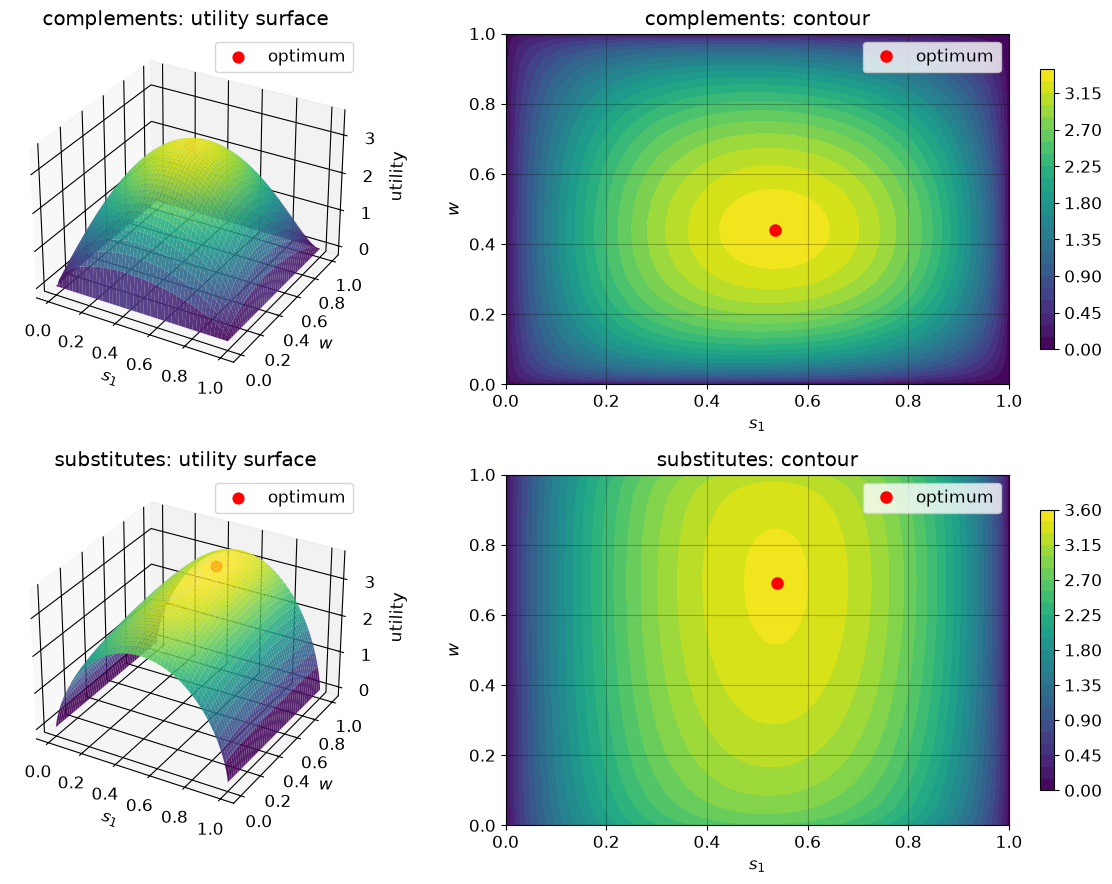

In [43]:
fig = plt.figure(figsize=(13,9))
for row,(name,m) in enumerate(models.items()):
    opt = grid[name]

    # a. 3D surface
    ax = fig.add_subplot(2,2,2*row+1,projection='3d')
    ax.plot_surface(opt.s1_grid,opt.w_grid,opt.u_grid,cmap='viridis',alpha=0.9)
    ax.scatter(opt.s1,opt.w,opt.u,color='red',s=60,label='optimum')
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$w$'); ax.set_zlabel('utility')
    ax.set_title(f'{name}: utility surface')
    ax.legend()

    # b. contour
    ax = fig.add_subplot(2,2,2*row+2)
    cs = ax.contourf(opt.s1_grid,opt.w_grid,opt.u_grid,levels=30,cmap='viridis')
    ax.plot(opt.s1,opt.w,'ro',ms=8,label='optimum')
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$w$')
    ax.set_title(f'{name}: contour'); ax.legend()
    fig.colorbar(cs,ax=ax,shrink=0.8)

fig.tight_layout()
plt.show()

The optimum sits inside the square in both cases. The contour spacing already shows what section 2.1.4 asks about: the surface is more peaked in one calibration than the other.

### 2.1.3 Grid search: does more resolution help?

I run grid search for N = 50, 100, 500, 1000 and record the optimum, utility, and number of utility evaluations (N squared).

In [44]:
N_list = [50,100,500,1000]
for name,m in models.items():
    print(f'=== {name} ===')
    print(f'{"N":>6} {"s1":>10} {"w":>10} {"utility":>12} {"evals":>10}')
    for N in N_list:
        o = m.solve_grid(N=N,do_print=False)
        print(f'{N:>6} {o.s1:>10.5f} {o.w:>10.5f} {o.u:>12.7f} {o.n_eval:>10}')
    print()

=== complements ===
     N         s1          w      utility      evals
    50    0.53061    0.44898    3.4007477       2500
   100    0.53535    0.44444    3.4014822      10000
   500    0.53507    0.43888    3.4016744     250000
  1000    0.53554    0.43944    3.4016798    1000000

=== substitutes ===
     N         s1          w      utility      evals
    50    0.53061    0.69388    3.4845944       2500
   100    0.53535    0.69697    3.4850049      10000
   500    0.53908    0.69138    3.4850971     250000
  1000    0.53854    0.69269    3.4851035    1000000



Utility barely changes after N = 100. The gain from a finer grid shrinks quickly while the cost grows as N squared (from 2,500 to 1,000,000 evaluations). (s1,w) keeps moving a bit in the last decimals, because a grid can only land on its own points, so the improvement is not perfectly smooth. That is the weakness of grid search: to halve the error N has to roughly double, which quadruples the cost. That is the reason to use the gradient based method in 2.2.

### 2.1.4 Grid search: compare the calibrations

Which calibration is harder for an optimizer? I compare the two surfaces along a slice through the optimum.

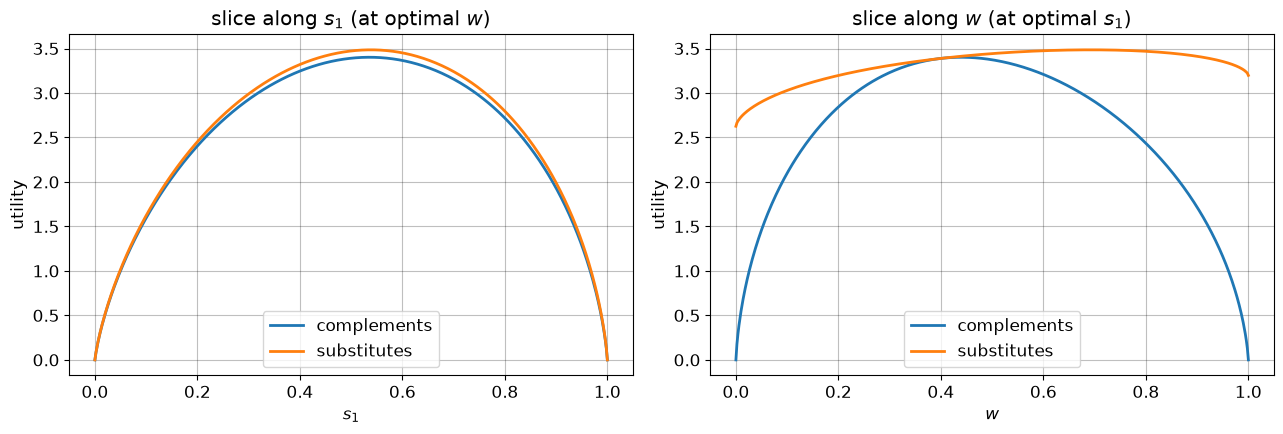

In [45]:
fig,axes = plt.subplots(1,2,figsize=(13,4.5))

# a. slice in s1 at the optimal w
ax = axes[0]
for name,m in models.items():
    o = grid[name]
    j = np.argmin(np.abs(o.w_grid[0,:]-o.w))   # column nearest optimal w
    ax.plot(o.s1_grid[:,j],o.u_grid[:,j],label=name,lw=2)
ax.set_xlabel('$s_1$'); ax.set_ylabel('utility'); ax.set_title('slice along $s_1$ (at optimal $w$)')
ax.legend()

# b. slice in w at the optimal s1
ax = axes[1]
for name,m in models.items():
    o = grid[name]
    i = np.argmin(np.abs(o.s1_grid[:,0]-o.s1))  # row nearest optimal s1
    ax.plot(o.w_grid[i,:],o.u_grid[i,:],label=name,lw=2)
ax.set_xlabel('$w$'); ax.set_ylabel('utility'); ax.set_title('slice along $w$ (at optimal $s_1$)')
ax.legend()

fig.tight_layout(); plt.show()

The w slice tells the story. For substitutes the surface is steep and peaked in w: swapping between bus and train changes utility a lot, so the optimizer gets a strong signal about which direction to go. For complements the surface is much flatter in w around the top, because the consumer wants a fixed mix of bus and train, so moving w around the optimum barely changes utility. A flat top gives weak gradient info, so I expect complements to be the harder one to hit precisely. The solver can stop anywhere in the flat region and still report success.

## 2.2 L-BFGS-B

### 2.2.1 Solve the model

L-BFGS-B is the workhorse from the course for smooth problems with few variables and simple bounds. Because the problem is written in shares, the bounds ((0,1),(0,1)) are the whole constraint set. I minimize objective, which is minus u (a minimizer minimizes, I maximize). I compare solution, evaluations and runtime with the grid.

In [46]:
for name,m in models.items():
    # grid timing
    t0 = time.perf_counter(); g = m.solve_grid(N=500,do_print=False); t_grid = time.perf_counter()-t0
    # L-BFGS-B timing
    t0 = time.perf_counter(); o = m.solve(do_print=False); t_opt = time.perf_counter()-t0

    print(f'=== {name} ===')
    print(f'  grid   : s1={g.s1:.5f}, w={g.w:.5f}, u={g.u:.7f}, evals={g.n_eval:>8}, {t_grid*1e3:7.1f} ms')
    print(f'  L-BFGS-B: s1={o.s1:.5f}, w={o.w:.5f}, u={o.u:.7f}, evals={o.nfev:>8}, {t_opt*1e3:7.1f} ms')
    print(f'  agree on utility: {np.isclose(g.u,o.u,atol=1e-4)}')
    check_solution(m,o)
    print()

=== complements ===
  grid   : s1=0.53507, w=0.43888, u=3.4016744, evals=  250000,    34.0 ms
  L-BFGS-B: s1=0.53562, w=0.43948, u=3.4016799, evals=      18,     2.1 ms
  agree on utility: True
  shares in (0,1): True | sum to one: True (1.00000000) | quantities > 0: True => PASS

=== substitutes ===
  grid   : s1=0.53908, w=0.69138, u=3.4850971, evals=  250000,    32.3 ms
  L-BFGS-B: s1=0.53823, w=0.69231, u=3.4851046, evals=      27,     2.6 ms
  agree on utility: True
  shares in (0,1): True | sum to one: True (1.00000000) | quantities > 0: True => PASS



The two methods agree to four decimals, but L-BFGS-B hits the answer in a few dozen evaluations against the grid's 250,000. Much cheaper and faster. That is check 2 from section 1.3, passed for both calibrations.

### 2.2.2 Record the convergence path

solve() stores every point the optimizer visits (via a callback) in opt.path. I draw the path on the contour plot and plot the distance to the final solution against the iteration number on a log scale.

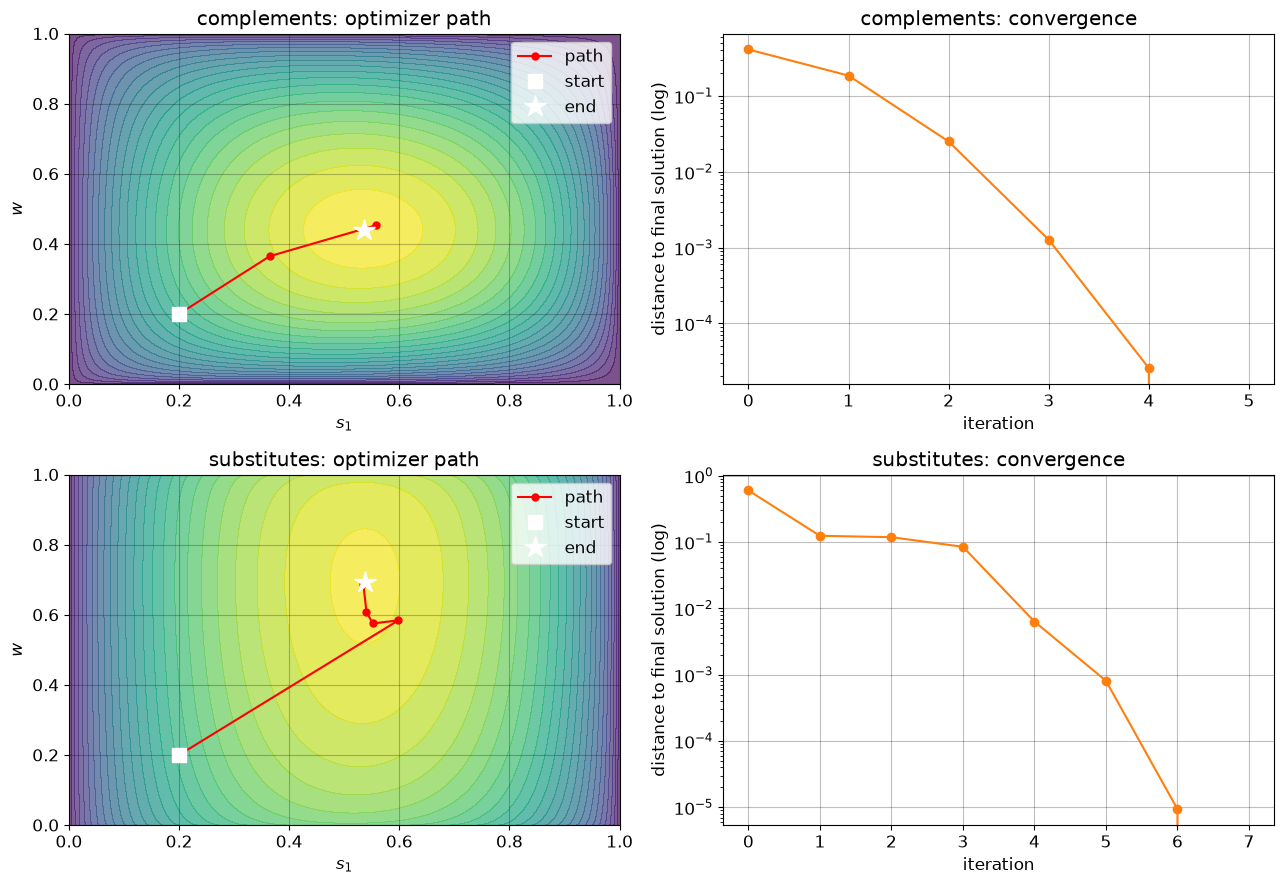

In [47]:
fig = plt.figure(figsize=(13,9))
for row,(name,m) in enumerate(models.items()):
    o = m.solve(s0=[0.2,0.2],do_print=False)   # start away from the optimum to see movement
    path = o.path
    final = path[-1]

    # a. path on the contour
    ax = fig.add_subplot(2,2,2*row+1)
    g = grid[name]
    ax.contourf(g.s1_grid,g.w_grid,g.u_grid,levels=30,cmap='viridis',alpha=0.7)
    ax.plot(path[:,0],path[:,1],'o-',color='red',ms=5,lw=1.5,label='path')
    ax.plot(path[0,0],path[0,1],'ws',ms=10,label='start')
    ax.plot(path[-1,0],path[-1,1],'w*',ms=16,label='end')
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$w$')
    ax.set_title(f'{name}: optimizer path'); ax.legend()

    # b. distance to final solution vs iteration
    ax = fig.add_subplot(2,2,2*row+2)
    dist = np.linalg.norm(path-final,axis=1)
    ax.semilogy(range(len(dist)),dist,'o-',color=colors[1])
    ax.set_xlabel('iteration'); ax.set_ylabel('distance to final solution (log)')
    ax.set_title(f'{name}: convergence')

fig.tight_layout(); plt.show()

The optimizer takes big steps in the first few iterations, where the gradient is steep and informative, and then slows down as it approaches the optimum and the gradient flattens out. That is the classic pattern of a straight line on a log plot when a method closes in on its target. Fast progress early, slow late.

### 2.2.3 Starting points

I solve from six starting points, the center, the four corners, and one extra, and record what happens for each. The problem warns that one corner fails in one calibration even though success=True. I find it and explain.

In [48]:
starts = {'center':[0.5,0.5],'corner (0,0)':[0,0],'corner (0,1)':[0,1],
          'corner (1,0)':[1,0],'corner (1,1)':[1,1],'extra (0.2,0.8)':[0.2,0.8]}

for name,m in models.items():
    u_true = m.solve_grid(N=1000,do_print=False).u
    print(f'=== {name} (grid utility ~ {u_true:.5f}) ===')
    print(f'{"start":>16} {"s1":>9} {"w":>9} {"utility":>11} {"nit":>5} {"nfev":>6} {"success":>8}  flag')
    for lbl,s0 in starts.items():
        o = m.solve(s0=s0,do_print=False)
        stuck = '  <-- STUCK at u=0' if abs(o.u-u_true)>1e-3 else ''
        print(f'{lbl:>16} {o.s1:>9.4f} {o.w:>9.4f} {o.u:>11.5f} {o.nit:>5} {o.nfev:>6} '
              f'{str(o.res.success):>8}{stuck}')
    print()

=== complements (grid utility ~ 3.40168) ===
           start        s1         w     utility   nit   nfev  success  flag
          center    0.5356    0.4395     3.40168     4     18     True
    corner (0,0)    0.5356    0.4395     3.40168     7     27     True
    corner (0,1)    0.5356    0.4395     3.40168     9     33     True
    corner (1,0)    1.0000    0.0000     0.00000     1     21     True  <-- STUCK at u=0
    corner (1,1)    1.0000    1.0000     0.00000     1     21     True  <-- STUCK at u=0
 extra (0.2,0.8)    0.5356    0.4395     3.40168     6     27     True

=== substitutes (grid utility ~ 3.48510) ===
           start        s1         w     utility   nit   nfev  success  flag
          center    0.5382    0.6923     3.48510     6     27     True
    corner (0,0)    0.5382    0.6923     3.48510    18     72     True
    corner (0,1)    0.5382    0.6923     3.48510    17     66     True
    corner (1,0)    0.5382    0.6923     3.48510    18     81     True
    corne

In substitutes all starting points reach the same optimum. In complements the two starting points with s1 = 1, corner (1,0) and (1,1), get stuck at u = 0 after a single iteration, but still report success=True.

Why. At s1 = 1 the consumer spends everything on food, so x2 = x3 = 0 and the travel composite is zero. With complements (sigma_B = 0.4, so rho_B < 0) one missing travel good makes the whole composite collapse, and utility is exactly zero. The gradient along that edge is also basically zero, so L-BFGS-B sees no direction to improve in, takes no step, and stops. It reports success because it has converged to a point where it cannot improve locally, even though that point is a corner minimum and not a maximum. With substitutes bus alone can replace train, so the composite is positive, the gradient points inward, and every starting point escapes.

The point: success=True only means the optimizer stopped cleanly, not that it found the global optimum. That is exactly why I solve from several starting points and cross check against the grid.

### 2.2.4 Numerical tolerances

I vary the objective tolerance ftol and the gradient tolerance gtol, and report the two shares, utility, and number of evaluations for each setting. Both go in options={...}.

In [49]:
ftols = [1e-4,1e-8,1e-12,1e-16]
gtols = [1e-2,1e-5,1e-8,1e-12]

for name,m in models.items():
    print(f'=== {name} ===')
    print('(a) varying ftol (gtol at default)')
    print(f'{"ftol":>8} {"s1":>10} {"w":>10} {"utility":>13} {"nfev":>6}')
    for ftol in ftols:
        o = m.solve(do_print=False,options={'ftol':ftol})
        print(f'{ftol:>8.0e} {o.s1:>10.6f} {o.w:>10.6f} {o.u:>13.9f} {o.nfev:>6}')
    print('(b) varying gtol (ftol at default)')
    print(f'{"gtol":>8} {"s1":>10} {"w":>10} {"utility":>13} {"nfev":>6}')
    for gtol in gtols:
        o = m.solve(do_print=False,options={'gtol':gtol})
        print(f'{gtol:>8.0e} {o.s1:>10.6f} {o.w:>10.6f} {o.u:>13.9f} {o.nfev:>6}')
    print()

=== complements ===
(a) varying ftol (gtol at default)
    ftol         s1          w       utility   nfev
   1e-04   0.535607   0.439652   3.401679632     15
   1e-08   0.535623   0.439479   3.401679876     18
   1e-12   0.535623   0.439479   3.401679876     18
   1e-16   0.535623   0.439479   3.401679876     18
(b) varying gtol (ftol at default)
    gtol         s1          w       utility   nfev
   1e-02   0.535607   0.439652   3.401679632     15
   1e-05   0.535623   0.439479   3.401679876     18
   1e-08   0.535624   0.439478   3.401679876     21
   1e-12   0.535624   0.439478   3.401679876     21

=== substitutes ===
(a) varying ftol (gtol at default)
    ftol         s1          w       utility   nfev
   1e-04   0.538155   0.691562   3.485103847     21
   1e-08   0.538225   0.692308   3.485104590     27
   1e-12   0.538225   0.692308   3.485104590     27
   1e-16   0.538225   0.692308   3.485104590     27
(b) varying gtol (ftol at default)
    gtol         s1          w       ut

A tighter tolerance gives more precision at first and then stops mattering: past a certain point the shares and utility no longer change while the number of evaluations keeps rising. Beyond about ftol=1e-12 the optimizer is chasing changes smaller than floating point noise (see the floating point lecture), so more evaluations give nothing.

### 2.2.5 Which settings would I use?

I do not know the analytical answer, but because the model maximizes utility, higher utility means a better numerical solution, so I can rank settings by the utility they reach, weighed against the cost.

In [50]:
print(f'{"calibration":>12} {"ftol":>8} {"utility":>13} {"nfev":>6}')
for name,m in models.items():
    for ftol in [1e-4,1e-8,1e-12,1e-16]:
        o = m.solve(do_print=False,options={'ftol':ftol})
        print(f'{name:>12} {ftol:>8.0e} {o.u:>13.9f} {o.nfev:>6}')

 calibration     ftol       utility   nfev
 complements    1e-04   3.401679632     15
 complements    1e-08   3.401679876     18
 complements    1e-12   3.401679876     18
 complements    1e-16   3.401679876     18
 substitutes    1e-04   3.485103847     21
 substitutes    1e-08   3.485104590     27
 substitutes    1e-12   3.485104590     27
 substitutes    1e-16   3.485104590     27


A tighter tolerance is not automatically better. Once utility has stopped improving, a smaller ftol just gives more evaluations (and runtime) for a solution that is the same to nine decimals. The sensible choice is the loosest tolerance that still reaches the best utility, here around ftol=1e-8 to 1e-10. It lands on the same optimum as the tightest setting but at a fraction of the cost. Tighter than that spends time resolving noise instead of economics.

## 3. Relative prices and demand

Now I use the model. Train tickets get more expensive and I look at what the consumer does. Everything reuses the two calibrations built in the setup above.

### 3.1 Vary the train price

I vary p3 over [0.5, 3.0] while keeping p1, p2 and I fixed. For every p3 I update the price, solve the model, and store the three budget shares and the three quantities. I reuse the same object and just change model.par.p3 in a loop, so nothing is duplicated.

In [51]:
N = 100
p3_grid = np.linspace(0.5,3.0,N)

# store results per calibration: shares (s1,s2,s3) and quantities (x1,x2,x3)
results = {}
for name,m in models.items():
    shares = np.zeros((N,3))
    quants = np.zeros((N,3))
    for i,p3 in enumerate(p3_grid):
        m.par.p3 = p3                    # a. update the price
        o = m.solve(do_print=False)      # b. solve at this price
        shares[i] = [o.s1,o.s2,o.s3]     # c. store budget shares
        quants[i] = m.quantities(o.s1,o.w)  # d. store quantities
    m.par.p3 = 1.5                       # reset to baseline afterwards
    results[name] = {'shares':shares,'quants':quants}

print('done, stored shares and quantities for', N, 'prices in each calibration')

done, stored shares and quantities for 100 prices in each calibration


Now I plot the budget shares and the quantities against p3, both calibrations.

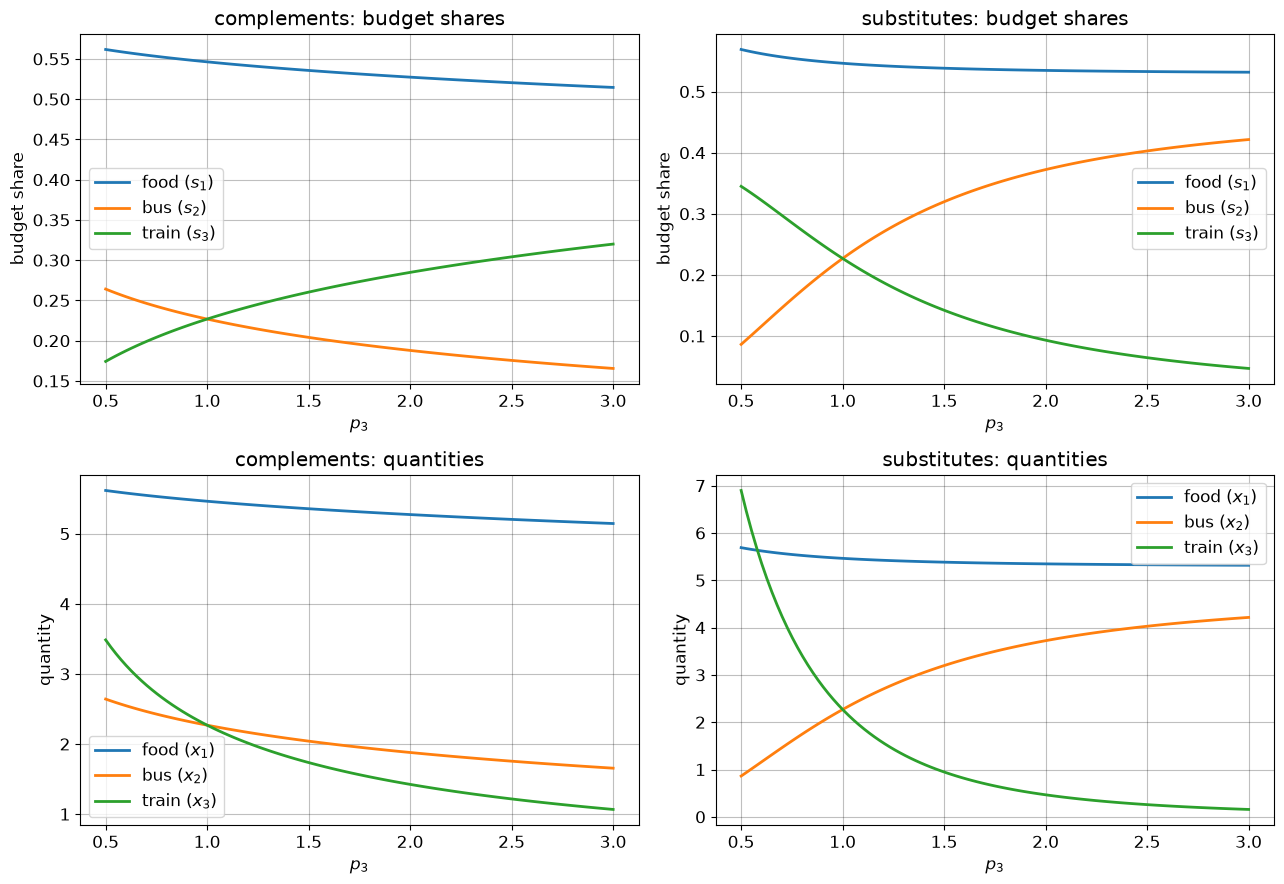

In [52]:
fig,axes = plt.subplots(2,2,figsize=(13,9))
labels = ['food ($s_1$)','bus ($s_2$)','train ($s_3$)']
qlabels = ['food ($x_1$)','bus ($x_2$)','train ($x_3$)']

for col,(name,m) in enumerate(models.items()):
    sh = results[name]['shares']
    qt = results[name]['quants']

    # top row: budget shares
    ax = axes[0,col]
    for k in range(3):
        ax.plot(p3_grid,sh[:,k],label=labels[k],lw=2)
    ax.set_xlabel('$p_3$'); ax.set_ylabel('budget share')
    ax.set_title(f'{name}: budget shares'); ax.legend()

    # bottom row: quantities
    ax = axes[1,col]
    for k in range(3):
        ax.plot(p3_grid,qt[:,k],label=qlabels[k],lw=2)
    ax.set_xlabel('$p_3$'); ax.set_ylabel('quantity')
    ax.set_title(f'{name}: quantities'); ax.legend()

fig.tight_layout(); plt.show()

### 3.2 What happens to the train share?

The question is about the budget share s3 = p3*x3/I, so I look at the slope of the s3 curve against p3 in each calibration.

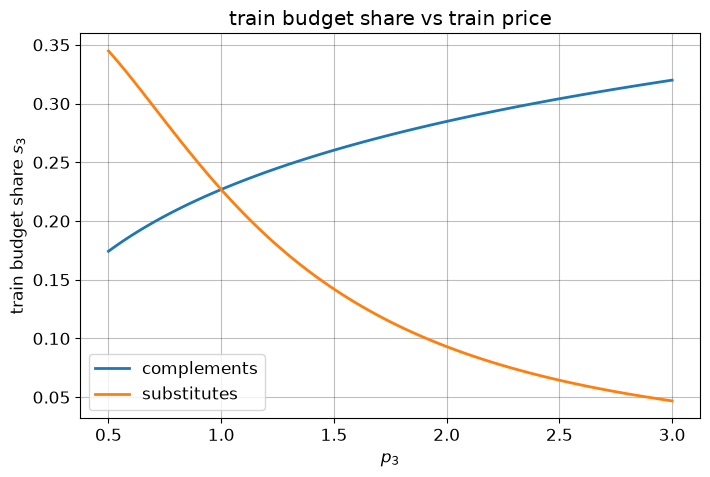

complements: s3 goes from 0.1742 at p3=0.5 to 0.3200 at p3=3.0
substitutes: s3 goes from 0.3449 at p3=0.5 to 0.0468 at p3=3.0


In [53]:
fig,ax = plt.subplots(figsize=(8,5))
for name,m in models.items():
    s3 = results[name]['shares'][:,2]
    ax.plot(p3_grid,s3,label=name,lw=2)
ax.set_xlabel('$p_3$'); ax.set_ylabel('train budget share $s_3$')
ax.set_title('train budget share vs train price'); ax.legend()
plt.show()

for name,m in models.items():
    s3 = results[name]['shares'][:,2]
    print(f'{name}: s3 goes from {s3[0]:.4f} at p3=0.5 to {s3[-1]:.4f} at p3=3.0')

In complements a higher p3 raises the train budget share, and in substitutes it lowers it.

The reason is the substitution between bus and train. In complements the consumer wants a roughly fixed mix of bus and train and cannot drop the train, so demand is inelastic: when p3 rises, x3 falls only a little, and p3*x3 (so s3) still goes up. In substitutes the consumer switches to bus when train gets expensive, so x3 falls sharply, and the fall in x3 outweighs the higher price, so s3 goes down.

### 3.3 Bus demand

Here the question is about the quantity of bus trips x2, not the bus share. I reuse the stored quantities from 3.1.

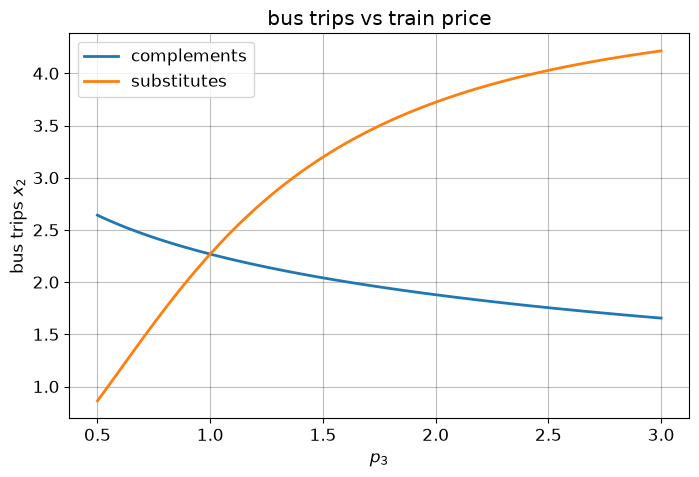

complements: x2 goes from 2.641 at p3=0.5 to 1.655 at p3=3.0
substitutes: x2 goes from 0.862 at p3=0.5 to 4.215 at p3=3.0


In [54]:
fig,ax = plt.subplots(figsize=(8,5))
for name,m in models.items():
    x2 = results[name]['quants'][:,1]
    ax.plot(p3_grid,x2,label=name,lw=2)
ax.set_xlabel('$p_3$'); ax.set_ylabel('bus trips $x_2$')
ax.set_title('bus trips vs train price'); ax.legend()
plt.show()

for name,m in models.items():
    x2 = results[name]['quants'][:,1]
    print(f'{name}: x2 goes from {x2[0]:.3f} at p3=0.5 to {x2[-1]:.3f} at p3=3.0')

The two calibrations pull in opposite directions. In substitutes bus and train are interchangeable, so when train gets more expensive the consumer moves onto the bus and x2 rises a lot. In complements bus and train are used together, so a higher train price drags bus demand down slightly as well, because the consumer buys less travel overall. This is the core economic difference: substitutes shift demand between the two travel goods, complements move them in the same direction.

### 3.4 Food versus bus demand

Now I compare how much the train price changes food demand x1 against bus demand x2, on a common x axis.

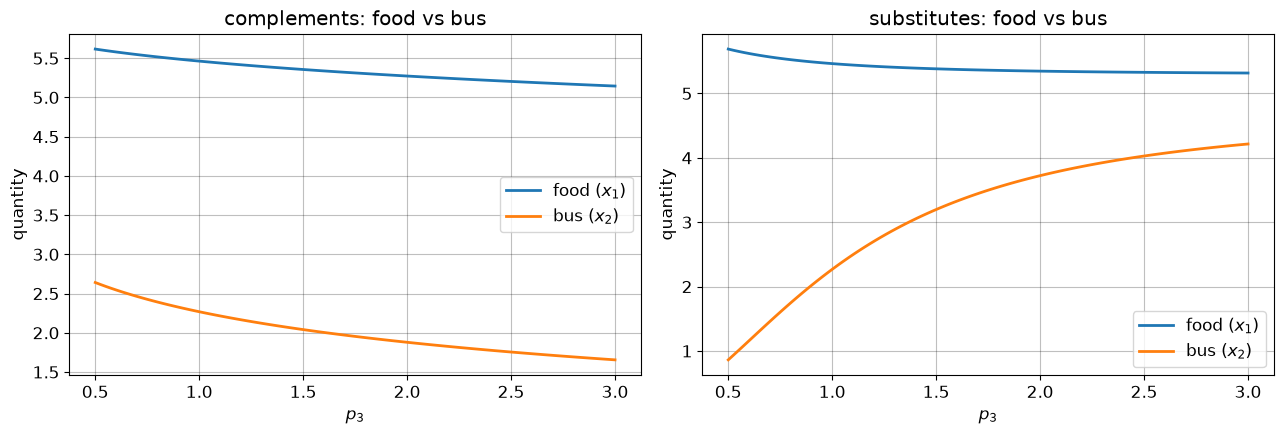

complements: change in food = -0.471, change in bus = -0.986
substitutes: change in food = -0.372, change in bus = +3.353


In [55]:
fig,axes = plt.subplots(1,2,figsize=(13,4.5),sharex=True)
for col,(name,m) in enumerate(models.items()):
    qt = results[name]['quants']
    ax = axes[col]
    ax.plot(p3_grid,qt[:,0],label='food ($x_1$)',lw=2)
    ax.plot(p3_grid,qt[:,1],label='bus ($x_2$)',lw=2)
    ax.set_xlabel('$p_3$'); ax.set_ylabel('quantity')
    ax.set_title(f'{name}: food vs bus'); ax.legend()
fig.tight_layout(); plt.show()

for name,m in models.items():
    qt = results[name]['quants']
    dx1 = qt[-1,0]-qt[0,0]
    dx2 = qt[-1,1]-qt[0,1]
    print(f'{name}: change in food = {dx1:+.3f}, change in bus = {dx2:+.3f}')

Food demand barely moves in either calibration, while bus demand changes a lot. That tells me the train price mainly changes the allocation inside the travel nest, between bus and train, and does very little to the split between food and travel in the upper nest. The nested structure is what produces this: p3 lives inside the travel nest, so it first reshuffles bus against train, and only reaches food indirectly through the travel composite, where the effect is small.

## 5. Extension – preference for food

As an extension, I investigate how the consumer's preference for food affects the response to changes in the train price.

In the baseline model, the preference weight on food is $\alpha=0.60$. A higher value of $\alpha$ means that food receives a larger weight in the upper CES nest, while a lower value means that travel receives a larger weight.

I consider three values of $\alpha$: $0.40$, $0.60$ and $0.80$. For each value, I vary the train price $p_3$ from 0.5 to 3.0, while keeping the other parameters fixed. I then compare how food and travel demand respond to changes in the train price.

This extension allows me to examine whether the effect of a change in the price of train travel depends on how strongly the consumer prefers food relative to travel.



In [56]:
# three calibrations with different preferences for food
model_a04 = ConsumerClass(par={'alpha':0.4})
model_a06 = ConsumerClass(par={'alpha':0.6})
model_a08 = ConsumerClass(par={'alpha':0.8})

models_alpha = {
    'alpha = 0.4': model_a04,
    'alpha = 0.6': model_a06,
    'alpha = 0.8': model_a08}

### 5.1 Varying the train price

I now vary the train price $p_3$ from 0.5 to 3.0 for each value of $\alpha$. The other prices, income and substitution parameters are kept at their baseline values.

For each combination of $\alpha$ and $p_3$, I solve the consumer's optimization problem and store the quantities of food, bus and train.


In [57]:
N = 100
p3_grid = np.linspace(0.5, 3.0, N)

# store quantities for each alpha
results_alpha = {}

for name, m in models_alpha.items():
    
    quants = np.zeros((N,3))
    
    for i, p3 in enumerate(p3_grid):
        m.par.p3 = p3
        o = m.solve(do_print=False)
        
        quants[i] = m.quantities(o.s1, o.w)
    
    # reset price to baseline
    m.par.p3 = 1.5
    
    results_alpha[name] = quants

print('done')

done


### 5.2 Food and travel demand

I first compare food demand across the three values of $\alpha$. Since $\alpha$ determines the weight placed on food in the upper nest, I expect food demand to become relatively more important as $\alpha$ increases.

I then compare bus and train demand to see whether the effect of a higher train price differs depending on the consumer's preference for food.


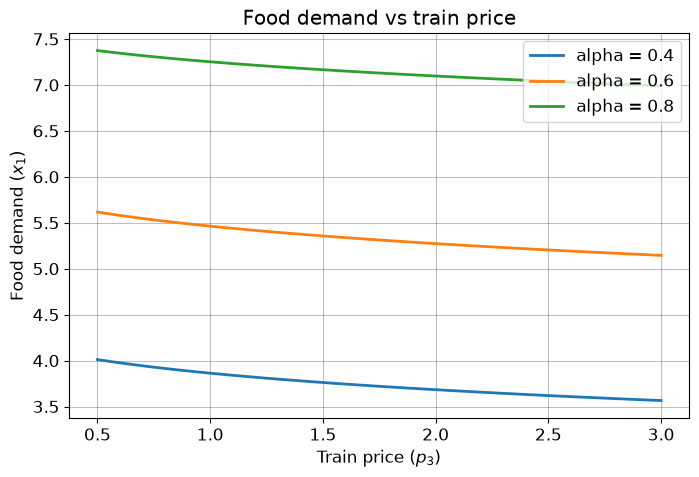

In [64]:
fig, ax = plt.subplots(figsize=(8,5))

for name, qt in results_alpha.items():
    ax.plot(p3_grid, qt[:,0], label=name, lw=2)

ax.set_xlabel('Train price ($p_3$)')
ax.set_ylabel('Food demand ($x_1$)')
ax.set_title('Food demand vs train price')
ax.legend()

plt.show()

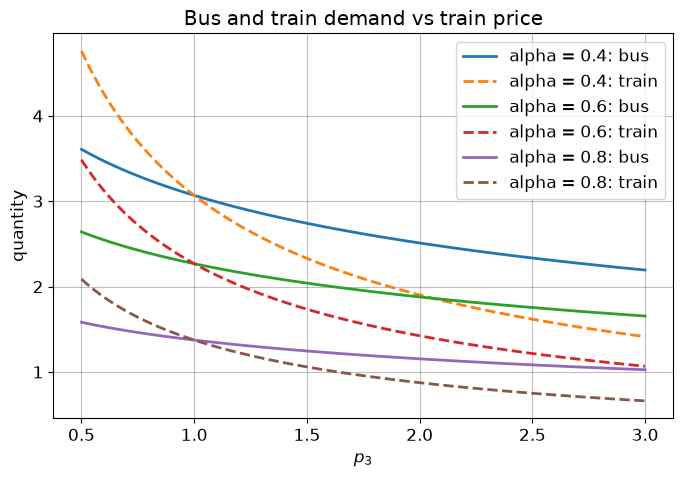

In [65]:
fig, ax = plt.subplots(figsize=(8,5))

for name, qt in results_alpha.items():
    ax.plot(p3_grid, qt[:,1], label=f'{name}: bus', lw=2)
    ax.plot(p3_grid, qt[:,2], '--', label=f'{name}: train', lw=2)

ax.set_xlabel('$p_3$')
ax.set_ylabel('quantity')
ax.set_title('Bus and train demand vs train price')
ax.legend()

plt.show()

### 5.3 Results

The results show that the preference for food affects how the consumer allocates income between food and travel.

When $\alpha$ is low, travel receives a relatively larger weight in the upper nest. The consumer therefore spends a larger part of the budget on travel. When $\alpha$ is high, food receives a larger weight, and the consumer allocates relatively more of the budget to food.

The response to an increase in the train price is therefore also affected by $\alpha$. A higher train price makes train travel more expensive, but the size of the resulting change in food and travel demand depends on how important travel is in the consumer's preferences.

The effect is particularly visible when comparing $\alpha=0.40$ with $\alpha=0.80$. With $\alpha=0.40$, travel is relatively important, so changes in the price of train travel have a larger effect on the allocation of the consumer's budget. With $\alpha=0.80$, food has a larger weight, so the consumer's allocation is less focused on travel.

Overall, the extension shows that the response to a price change does not only depend on the substitution possibilities between bus and train. It also depends on the consumer's preferences between the upper-level categories of food and travel.


In [66]:
print(f'{"alpha":>10} {"food change":>15} {"bus change":>15} {"train change":>17}')

for name, qt in results_alpha.items():
    dx1 = qt[-1,0] - qt[0,0]
    dx2 = qt[-1,1] - qt[0,1]
    dx3 = qt[-1,2] - qt[0,2]
    
    print(f'{name:>10} {dx1:>15.3f} {dx2:>15.3f} {dx3:>17.3f}')

     alpha     food change      bus change      train change
alpha = 0.4          -0.446          -1.414            -3.347
alpha = 0.6          -0.471          -0.986            -2.418
alpha = 0.8          -0.384          -0.556            -1.426


### 5.4 Conclusion

The extension shows that the consumer's preference structure matters for the response to a price change.

Changing $\alpha$ changes the relative importance of food and travel in the consumer's utility function. Consequently, the same increase in the train price can lead to different changes in food, bus and train demand depending on the value of $\alpha$.

This extends the analysis from section 3 by showing that the effect of a relative price change depends not only on substitution between bus and train, but also on the consumer's preferences between food and travel.
